In [1]:
import glob
import os
from collections import defaultdict
from typing import Dict, List, Optional
import random
import copy
import numbers
import json

import numpy as np
import cv2
from scipy.io import wavfile
import torch
import torch.nn as nn
import torch.nn.functional as f
import moviepy.editor as mpy
from gym.spaces import Box
from moviepy.audio.AudioClip import CompositeAudioClip, AudioArrayClip

from habitat.utils.visualizations.utils import images_to_video
from habitat import logger
from habitat_sim.utils.common import d3_40_colors_rgb
from ss_baselines.common.tensorboard_utils import TensorboardWriter
from habitat.utils.visualizations import maps
from habitat.utils.visualizations.utils import draw_collision

2025-07-31 10:36:33.965922: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-31 10:36:33.983873: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-31 10:36:33.983895: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-31 10:36:33.983905: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-31 10:36:33.987531: I tensorflow/core/platform/cpu_feature_g

In [2]:
import sys
 
from module import *

2025-07-31 10:36:36,073	INFO util.py:159 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [5]:
def reset_env(episode):

    # env data location 
    scene_path = '/home/getuanhui/project/sound-spaces/data/scene_datasets/mp3d/'
    audio_path = '/home/getuanhui/project/sound-spaces/data/sounds/1s_all_distractor/train'


    info = episode['info'] # to get the sound object
    scene = f"{scene_path}/{episode['scene_id']}" # get the env scene
    sound = f"{audio_path}/{info['sound']}.wav" # get the sound object

    agent_pos= episode['start_position'] # get the agent start_position
    audio_pos= episode['goals'][0]['position'] # get the sound position

    
    env_config['scene_dir'] = scene
    env_config['audio_dir'] = sound

    env = Env(env_config)



    # 防止出现环境中error的问题，出现问题就跳过
    if env._if_find_path_isNone(agent_id=0 , goal_pos=[np.array(audio_pos)] , agent_pos=[np.array(agent_pos)]): # 单个agent ，后续多agent可以使用for i in agentnum
        
        logging.error(f"env error ! raise habitat_sim.errors.GreedyFollowerError this episode {episode['episode_id']} jump")
        env.__clear__()
        return None
    
    env.reset(audio_pos = [np.array(audio_pos)], agent_pos = [np.array(agent_pos)])

    print(f"reset_env success . init scene {episode['scene_id']} and sound {info['sound']}")
    logging.info(f"reset_env success . init scene {episode['scene_id']} and sound {info['sound']}")

    return env

In [7]:
config = train_config['episodes'][0]
env = reset_env(config)

[10:37:26:203005]:[Metadata] SceneDatasetAttributesManager.cpp(308)::readDatasetJSONCell : "stages.default_attributes" set in Attributes Manager from JSON.
[10:37:26:215289]:[Metadata] AttributesManagerBase.h(352)::buildAttrSrcPathsFromJSONAndLoad : Glob path result for /home/getuanhui/project/sound-spaces/data/scene_datasets/mp3d/*/*.glb : /home/getuanhui/project/sound-spaces/data/scene_datasets/mp3d/17DRP5sb8fy/17DRP5sb8fy.glb
[10:37:26:215639]:[Metadata] AttributesManagerBase.h(352)::buildAttrSrcPathsFromJSONAndLoad : Glob path result for /home/getuanhui/project/sound-spaces/data/scene_datasets/mp3d/*/*.glb : /home/getuanhui/project/sound-spaces/data/scene_datasets/mp3d/1LXtFkjw3qL/1LXtFkjw3qL.glb
[10:37:26:215866]:[Metadata] AttributesManagerBase.h(352)::buildAttrSrcPathsFromJSONAndLoad : Glob path result for /home/getuanhui/project/sound-spaces/data/scene_datasets/mp3d/*/*.glb : /home/getuanhui/project/sound-spaces/data/scene_datasets/mp3d/1pXnuDYAj8r/1pXnuDYAj8r.glb
[10:37:26:216

[array([-1.4323277e+01,  2.3523000e-02, -2.4397861e+01])]
agent 0 initialization retried.
agent_state.position [ -6.323277  -0.019705 -16.397861]
CreateContext: Context created
[array([-1.4323277e+01,  2.3523000e-02, -2.4397861e+01])]
agent 0 initialization retried.
agent_state.position [ -6.323277  -0.019705 -16.397861]
reset_env success . init scene ur6pFq6Qu1A/ur6pFq6Qu1A.glb and sound horn_1


Material for category 'objects' was not found. Using default material instead.
Material for category 'picture' was not found. Using default material instead.
Material for category 'void' was not found. Using default material instead.
Material for category 'column' was not found. Using default material instead.


In [43]:
sim  = env._sim

In [44]:
top_down_map = maps.get_topdown_map_from_sim(sim)

In [48]:
top_down_map.shape

(1104, 1024)

In [45]:
color_top_down_map = maps.colorize_topdown_map(top_down_map)

In [1]:
import pickle , os
path = '../experiment/data/test_draw_path/'
files = [os.path.join(path , i) for i in os.listdir(path)]

In [2]:
with open(files[0] , 'rb') as f:
    data = pickle.load(f)

In [3]:
path_points = data[2]

In [33]:
path_points_2d = [ (int(p[0]), int(p[2])) for p in path_points ]

In [34]:
path_points_2d 

[(-6, -16),
 (-6, -16),
 (-6, -16),
 (-6, -16),
 (-6, -16),
 (-6, -16),
 (-6, -17),
 (-6, -17),
 (-6, -17),
 (-6, -17),
 (-6, -17),
 (-6, -17),
 (-7, -17),
 (-7, -17),
 (-7, -17),
 (-7, -17),
 (-7, -17),
 (-7, -17),
 (-7, -17),
 (-7, -17),
 (-7, -18),
 (-8, -18),
 (-8, -18),
 (-8, -18),
 (-8, -18),
 (-8, -18),
 (-8, -18),
 (-8, -18),
 (-8, -18),
 (-8, -18),
 (-8, -18),
 (-9, -18),
 (-9, -18),
 (-9, -18),
 (-9, -18),
 (-9, -18),
 (-9, -18),
 (-9, -18),
 (-9, -18),
 (-9, -18),
 (-10, -18),
 (-10, -18),
 (-10, -18),
 (-10, -19),
 (-10, -19),
 (-10, -19),
 (-10, -19),
 (-11, -19),
 (-11, -19),
 (-11, -19),
 (-11, -19),
 (-11, -19),
 (-11, -19),
 (-11, -19),
 (-11, -19),
 (-12, -19),
 (-12, -20),
 (-12, -20),
 (-12, -20),
 (-12, -20),
 (-12, -20),
 (-12, -20),
 (-12, -20),
 (-12, -20),
 (-12, -20),
 (-12, -21),
 (-12, -21),
 (-13, -21),
 (-13, -21),
 (-13, -21),
 (-13, -21),
 (-13, -21),
 (-13, -21),
 (-13, -21),
 (-13, -22),
 (-13, -22),
 (-13, -22),
 (-13, -22),
 (-13, -22),
 (-13, -22),


In [46]:
maps.draw_path(color_top_down_map , path_points_2d,thickness=10)

In [49]:
path_points_map = [
    maps.to_grid(p[2], p[0], grid_resolution=(1104, 1024), sim=sim) for p in path_points
]


In [61]:
maps.draw_agent(color_top_down_map,path_points_map[0],0.0,agent_radius_px=10)
maps.draw_path(color_top_down_map, path_points_map, color=10, thickness=2)

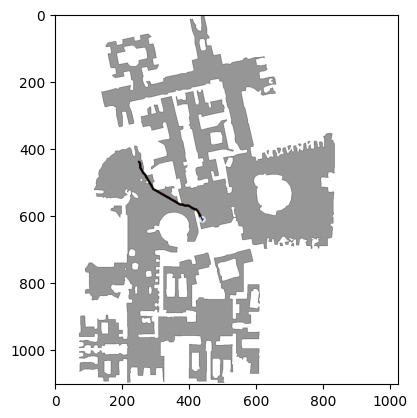

In [62]:
from matplotlib import pyplot as plt 
plt.imshow(color_top_down_map)